In [10]:
import pandas as pd
from pathlib import Path

data_dir = Path("../data/aqar")
df=pd.read_csv(data_dir / "aqar_listing.csv")

pd.set_option("display.max_columns",None)
df.columns


Index(['id', 'title', 'url', 'price', 'meter_price', 'price_2_payments',
       'price_4_payments', 'price_12_payments', 'rnpl_monthly_price',
       'area_sqm', 'deed_area', 'num_bedrooms', 'num_bathrooms',
       'num_living_rooms', 'num_kitchens', 'num_rooms', 'floor_level',
       'furnished', 'duplex', 'ac', 'lift', 'maid_room', 'driver_room', 'pool',
       'basement', 'backyard', 'playground', 'car_entrance', 'stairs',
       'water_availability', 'electrical_availability',
       'drainage_availability', 'private_roof', 'two_entrances',
       'special_entrance', 'apartment_in_villa', 'street_width', 'direction',
       'city', 'district', 'address', 'latitude', 'longitude', 'category_id',
       'category_ga_listing_type', 'category_ga_property_category',
       'category_is_rent', 'category_name', 'category_en', 'category_plural',
       'category_uri', 'category_path', 'category_keywords',
       'category_description', 'category_index', 'sale_type', 'is_rental',
       'is_

- [x] Use Y-data
- [] try multi layer preceptron(loss-funtion MSE, opt: adamw, Activation: Leaky ReLU)
- [x] try a Layered ML model(Use three diffrent ml models, they output to the forth)
  - Didn't Work Had Worse R^2 Values


array([[<Axes: title={'center': 'id'}>,
        <Axes: title={'center': 'price'}>,
        <Axes: title={'center': 'meter_price'}>,
        <Axes: title={'center': 'price_2_payments'}>,
        <Axes: title={'center': 'price_4_payments'}>],
       [<Axes: title={'center': 'price_12_payments'}>,
        <Axes: title={'center': 'rnpl_monthly_price'}>,
        <Axes: title={'center': 'area_sqm'}>,
        <Axes: title={'center': 'deed_area'}>,
        <Axes: title={'center': 'num_bedrooms'}>],
       [<Axes: title={'center': 'num_bathrooms'}>,
        <Axes: title={'center': 'num_living_rooms'}>,
        <Axes: title={'center': 'num_kitchens'}>,
        <Axes: title={'center': 'num_rooms'}>,
        <Axes: title={'center': 'floor_level'}>],
       [<Axes: title={'center': 'street_width'}>,
        <Axes: title={'center': 'latitude'}>,
        <Axes: title={'center': 'longitude'}>,
        <Axes: title={'center': 'category_id'}>,
        <Axes: title={'center': 'category_index'}>],
       

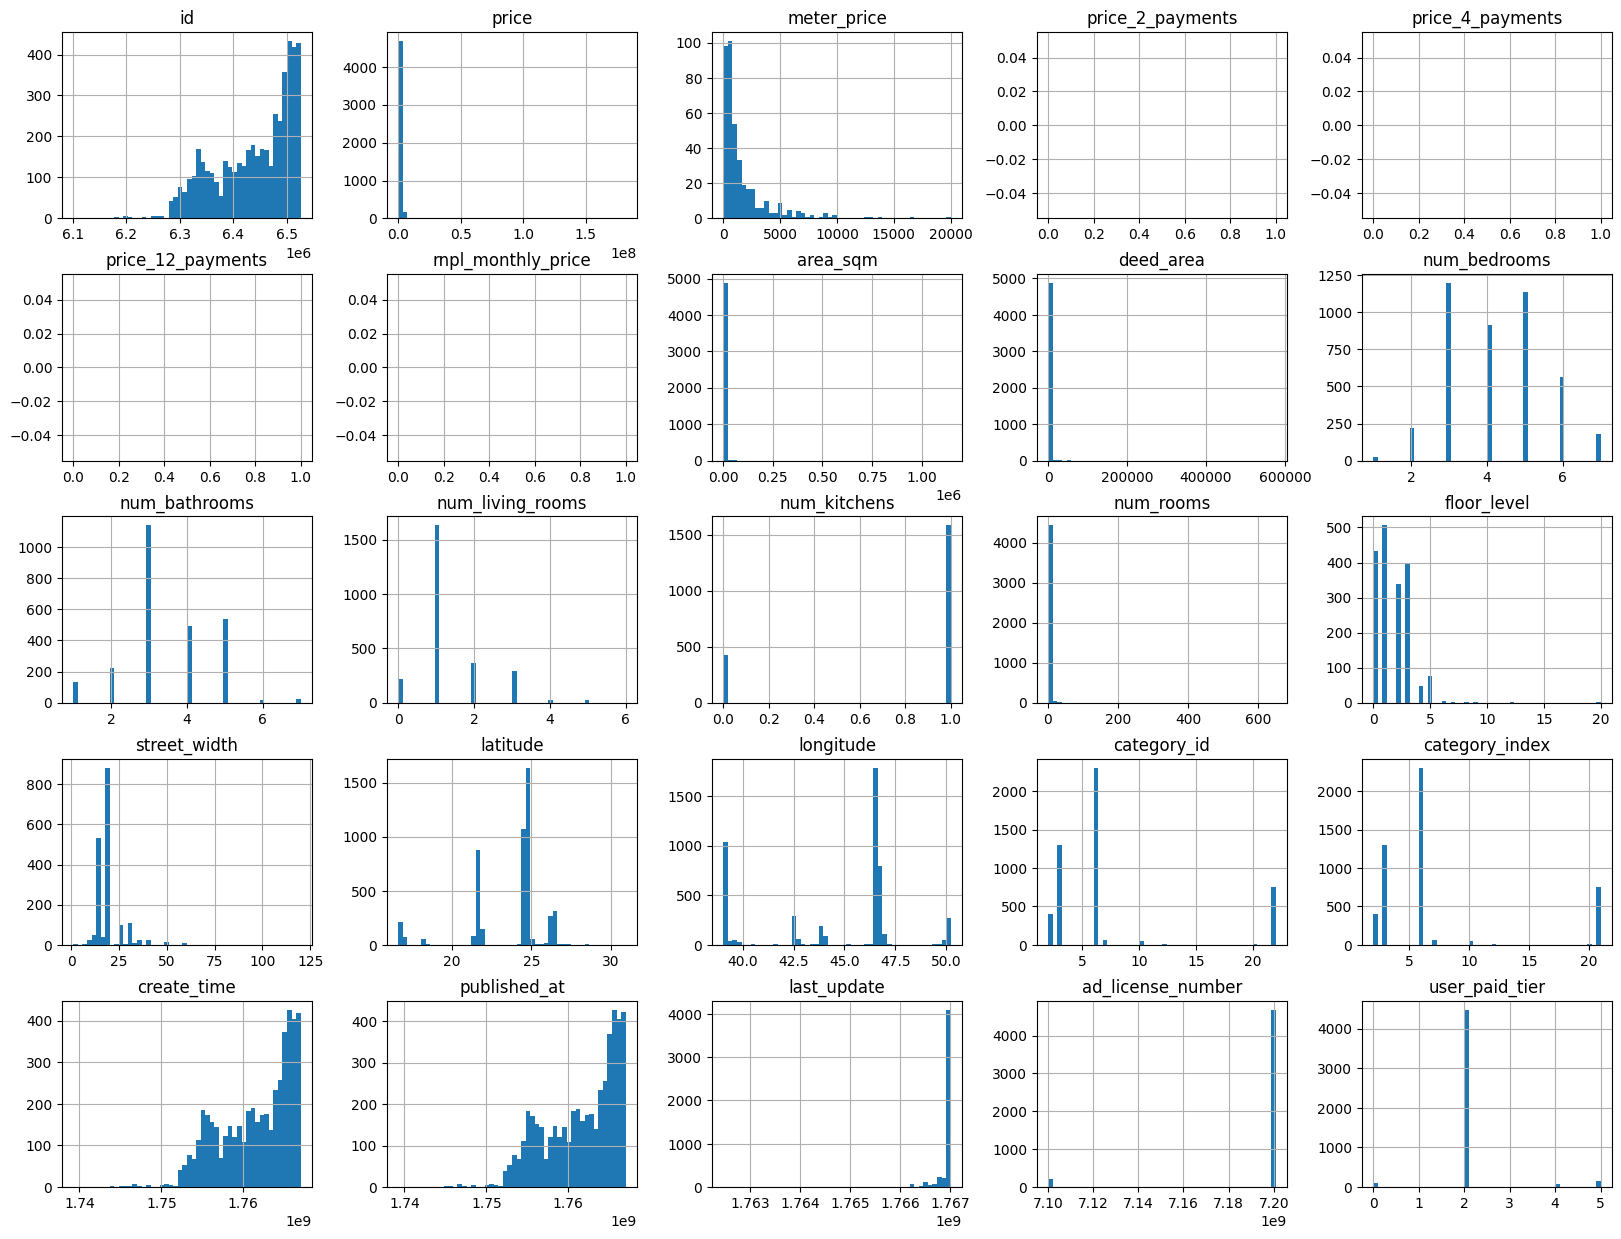

In [11]:
df.hist(bins=50, figsize=(20,15))

In [12]:

num_feature_cols=["area_sqm","num_bathrooms","num_bedrooms","num_rooms"]
cat_feature_cols=["location","category_ga_property_category"]
bool_feature_cols=["lift"]

pd.set_option('future.no_silent_downcasting', True)
# drop listings of land without buildings
df : pd.DataFrame = df[df['category_ga_property_category'] != 'land'].copy()
# drop listings of commercial buildings
df : pd.DataFrame = df[(df["category_ga_property_category"]!= "office") & (df["category_ga_property_category"]!="store") & (df["category_ga_property_category"]!="warehouse") & (df["category_ga_property_category"]!="lounge")].copy()

for bool_col in bool_feature_cols:
    df[bool_col] = df[bool_col].astype(int)
df['location'] = df['city'] + '_' + df['district']

target_col=["price"]


df[num_feature_cols + cat_feature_cols + bool_feature_cols + target_col].head(10)


,area_sqm,num_bathrooms,num_bedrooms,num_rooms,location,category_ga_property_category,lift,price
0,116.0,3.0,4.0,4.0,الرياض_حي النرجس,floor,0,1500000.0
1,700.0,5.0,7.0,7.0,الرياض_حي الملقا,villa,1,13500000.0
2,215.0,NaN,6.0,6.0,ابها_حي دره المنسك,apartment,0,635000.0
3,169.0,NaN,5.0,5.0,ابها_حي ابها الجديده,apartment,0,510000.0
4,208.0,NaN,6.0,6.0,ابها_حي القريقر,apartment,0,540000.0
5,127.0,3.0,4.0,4.0,جده_حي البوادي,apartment,1,558000.0
6,736.0,3.0,2.0,2.0,الرياض_حي المهديه,apartment,1,717000.0
7,201.0,NaN,6.0,6.0,خميس مشيط_حي النهضه,apartment,0,550000.0
8,200.0,5.0,4.0,4.0,الرياض_حي عكاظ,floor,0,695000.0
9,223.0,NaN,6.0,6.0,خميس مشيط_حي النهضه,apartment,0,530000.0


array([[<Axes: title={'center': 'area_sqm'}>,
        <Axes: title={'center': 'num_bathrooms'}>],
       [<Axes: title={'center': 'num_bedrooms'}>,
        <Axes: title={'center': 'num_rooms'}>],
       [<Axes: title={'center': 'lift'}>,
        <Axes: title={'center': 'price'}>]], dtype=object)

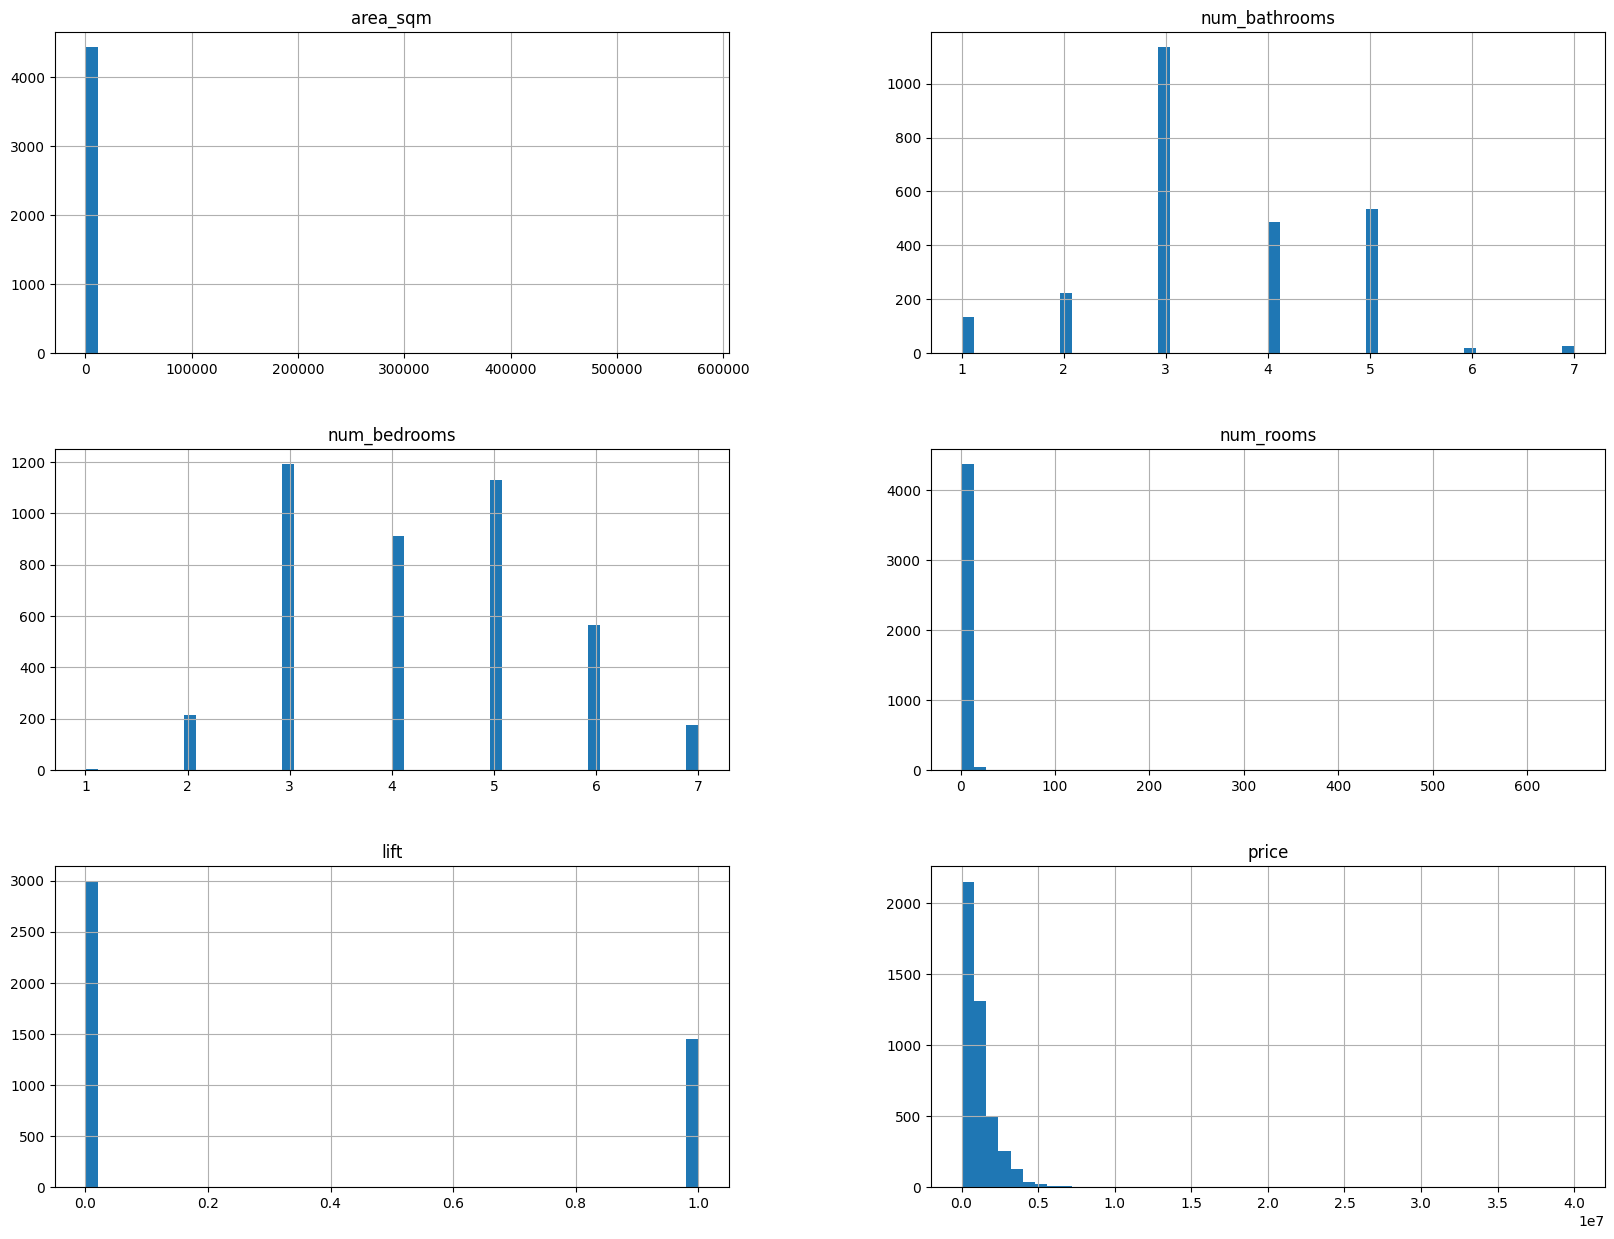

In [13]:
df[num_feature_cols + cat_feature_cols + bool_feature_cols + target_col].hist(bins=50, figsize=(20,15))

In [14]:
# Model Training and Evaluation before preprocessing pipeline
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import cross_val_score
from sklearn.metrics import mean_squared_error, r2_score
from sklearn.model_selection import GridSearchCV
from sklearn.model_selection import cross_val_score
import numpy as np
from sklearn.base import BaseEstimator, TransformerMixin, OneToOneFeatureMixin
from sklearn.utils._set_output import _SetOutputMixin

class RareLabelGrouper(OneToOneFeatureMixin, TransformerMixin, BaseEstimator):
    _parameter_constraints = {}
    
    def __init__(self, tol=0.01, replace_with='Other'):
        self.tol = tol
        self.replace_with = replace_with

    def fit(self, X, y=None):
        # Store feature names
        if isinstance(X, pd.DataFrame):
            self.feature_names_in_ = X.columns.to_numpy()
        else:
            self.feature_names_in_ = np.array([f"x{i}" for i in range(X.shape[1])])
        
        # Learn frequent labels
        self.frequent_labels_ = {}
        X_df = pd.DataFrame(X, columns=self.feature_names_in_)
        for col in X_df.columns:
            counts = pd.Series(X_df[col]).value_counts(normalize=True)
            self.frequent_labels_[col] = counts[counts >= self.tol].index
        return self

    def transform(self, X):
        X_df = pd.DataFrame(X, columns=self.feature_names_in_).copy()
        for col in X_df.columns:
            known_labels = self.frequent_labels_.get(col, [])
            X_df[col] = X_df[col].where(X_df[col].isin(known_labels), self.replace_with)
        return X_df
    
    def get_feature_names_out(self, input_features=None):
        """Required for pandas output support"""
        if input_features is None:
            return self.feature_names_in_
        return np.asarray(input_features, dtype=object)

from sklearn.preprocessing import FunctionTransformer

def compute_ratios(X):
    X = X.copy()
    # Add small epsilon to avoid division by zero
    X['sqm_per_room'] = X['area_sqm'] / (X['num_rooms'].replace(0, 1))
    X['bath_per_bed'] = X['num_bathrooms'] / (X['num_bedrooms'].replace(0, 1))
    return X

ratio_adder = FunctionTransformer(compute_ratios, validate=False)

In [15]:

# Data Pipeline
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler, OneHotEncoder, RobustScaler, TargetEncoder, PolynomialFeatures

pipe1= ColumnTransformer([
    ("num_pipeline", Pipeline([
        ("imputer", SimpleImputer(strategy="median")),
    ]), num_feature_cols),
    ("cat_pipeline", Pipeline([
        ("imputer", SimpleImputer(strategy="most_frequent")),
        ("onehot", OneHotEncoder(handle_unknown="ignore",sparse_output=False,min_frequency=0.001))
    ]), cat_feature_cols),
    ("bool_pipeline", Pipeline([
        ("imputer", SimpleImputer(strategy="constant", fill_value=0)),
    ]), bool_feature_cols)
])

pipe1_optimized = ColumnTransformer([
    ("num_pipeline", Pipeline([
        ("imputer", SimpleImputer(strategy="median")),
        ("ratios", ratio_adder),
    ]), num_feature_cols),
    ("cat_pipeline", Pipeline([
        ("imputer", SimpleImputer(strategy="most_frequent")),
        ("rare_grouper", RareLabelGrouper(tol=0.001, replace_with='other')), 
        ("target_enc", TargetEncoder())
    ]), cat_feature_cols),
    ("bool_pipeline", Pipeline([
        ("imputer", SimpleImputer(strategy="constant", fill_value=0)),
    ]), bool_feature_cols)
])

pipe1_optimized_scaled = ColumnTransformer([
    ("num_pipeline", Pipeline([
        ("imputer", SimpleImputer(strategy="median")),
        ("ratios", ratio_adder),
        ("scaler", RobustScaler())
    ]), num_feature_cols),
    ("cat_pipeline", Pipeline([
        ("imputer", SimpleImputer(strategy="most_frequent")),
        ("rare_grouper", RareLabelGrouper(tol=0.001, replace_with='other')), 
        ("target_enc", TargetEncoder())
    ]), cat_feature_cols),
    ("bool_pipeline", Pipeline([
        ("imputer", SimpleImputer(strategy="constant", fill_value=0)),
    ]), bool_feature_cols)
])
pipe2 = ColumnTransformer([
    ("num_pipeline", Pipeline([
        ("imputer", SimpleImputer(strategy="median")),
    ]), num_feature_cols),
    ("cat_pipeline", Pipeline([
        ("imputer", SimpleImputer(strategy="most_frequent")),
        ("target_enc", TargetEncoder())
    ]), cat_feature_cols),
    ("bool_pipeline", Pipeline([
        ("imputer", SimpleImputer(strategy="constant", fill_value=0)),
    ]), bool_feature_cols)
])

pipe2_optimized = ColumnTransformer([
    ("num_pipeline", Pipeline([
        ("imputer", SimpleImputer(strategy="median")),
        ("ratios", ratio_adder),
    ]), num_feature_cols),
    ("cat_pipeline", Pipeline([
        ("imputer", SimpleImputer(strategy="most_frequent")),
        ("target_enc", TargetEncoder())
    ]), cat_feature_cols),
    ("bool_pipeline", Pipeline([
        ("imputer", SimpleImputer(strategy="constant", fill_value=0)),
    ]), bool_feature_cols)
])



pipe3 = ColumnTransformer([
    ("num_pipeline", Pipeline([
        ("imputer", SimpleImputer(strategy="median")),
    ]), num_feature_cols),
    ("cat_pipeline", Pipeline([
        ("imputer", SimpleImputer(strategy="most_frequent")),
        ("rare_grouper", RareLabelGrouper(tol=0.001, replace_with='other')),
        ("target_enc", TargetEncoder())
    ]), cat_feature_cols),
    ("bool_pipeline", Pipeline([
        ("imputer", SimpleImputer(strategy="constant", fill_value=0)),
    ]), bool_feature_cols)
])
pipe4 = ColumnTransformer([
    ("num_pipeline", Pipeline([
        ("imputer", SimpleImputer(strategy="median")),
        ("scaler", RobustScaler())
    ]), num_feature_cols),
    ("cat_pipeline", Pipeline([
        ("imputer", SimpleImputer(strategy="most_frequent")),
        ("target_enc", TargetEncoder())
    ]), cat_feature_cols),
    ("bool_pipeline", Pipeline([
        ("imputer", SimpleImputer(strategy="constant", fill_value=0)),
    ]), bool_feature_cols)
])

pipe5_ratio_scaled = ColumnTransformer([
    ("num_pipeline", Pipeline([
        ("imputer", SimpleImputer(strategy="median")),
        ("ratios", ratio_adder),
        ("scaler", RobustScaler())
    ]), num_feature_cols),
    ("cat_pipeline", Pipeline([
        ("imputer", SimpleImputer(strategy="most_frequent")),
        ("target_enc", TargetEncoder())
    ]), cat_feature_cols),
    ("bool_pipeline", Pipeline([
        ("imputer", SimpleImputer(strategy="constant", fill_value=0)),
    ]), bool_feature_cols)
])

# With polynomial features (degree 2)
pipe6_poly = ColumnTransformer([
    ("num_pipeline", Pipeline([
        ("imputer", SimpleImputer(strategy="median")),
        ("ratios", ratio_adder),
        ("poly", PolynomialFeatures(degree=2, include_bias=False)),
        ("scaler", RobustScaler())
    ]), num_feature_cols),
    ("cat_pipeline", Pipeline([
        ("imputer", SimpleImputer(strategy="most_frequent")),
        ("rare_grouper", RareLabelGrouper(tol=0.001, replace_with='other')),
        ("target_enc", TargetEncoder())
    ]), cat_feature_cols),
    ("bool_pipeline", Pipeline([
        ("imputer", SimpleImputer(strategy="constant", fill_value=0)),
    ]), bool_feature_cols)
])

# Different rare label threshold
pipe7_rare_moderate = ColumnTransformer([
    ("num_pipeline", Pipeline([
        ("imputer", SimpleImputer(strategy="median")),
        ("ratios", ratio_adder),
        ("scaler", RobustScaler())
    ]), num_feature_cols),
    ("cat_pipeline", Pipeline([
        ("imputer", SimpleImputer(strategy="most_frequent")),
        ("rare_grouper", RareLabelGrouper(tol=0.005, replace_with='other')),
        ("target_enc", TargetEncoder())
    ]), cat_feature_cols),
    ("bool_pipeline", Pipeline([
        ("imputer", SimpleImputer(strategy="constant", fill_value=0)),
    ]), bool_feature_cols)
])



# Define features and target
X = df[num_feature_cols + cat_feature_cols + bool_feature_cols]
y = np.log1p(df[target_col])
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)


In [16]:
import os
import pickle
from pathlib import Path

def build_cache_path(pipeline_name:str, model_name:str,cols:list[str]) -> Path:
    colstr = "".join(cols)
    return Path(f"cache/models/_{pipeline_name}_{model_name}_{colstr}_model.pkl")

def cache_model(model, pipeline_name:str, model_name:str, cols:list[str]):
    cache_path = build_cache_path(pipeline_name, model_name, cols)
    cache_path.parent.mkdir(parents=True, exist_ok=True)
    with open(cache_path, 'wb') as f:
        pickle.dump(model, f)



In [17]:
# check balance on category type 
df['category_ga_property_category'].value_counts(normalize=True)

from sklearn.model_selection import RandomizedSearchCV

In [18]:

from sklearn.neighbors import KNeighborsRegressor
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import GradientBoostingRegressor,HistGradientBoostingRegressor
from xgboost import XGBRegressor
from sklearn.model_selection import cross_validate
import numpy as np

from sklearn.model_selection import cross_validate, GridSearchCV
import numpy as np

def evaluate_model(pipe_name, pipe, model_name, best_pipeline):
    result= {}
    fit_params = {}
    
    cv_results = cross_validate(
        best_pipeline,
        X_train,
        y_train.values.ravel(),
        cv=5,
        scoring=['r2', 'neg_root_mean_squared_error', 'neg_mean_absolute_error'],
        return_train_score=True,
        params=fit_params
    )
    
    result={
        'Pipeline': pipe_name,
        'Model': model_name,
        'Train R2': cv_results['train_r2'].mean(),
        'Test R2': cv_results['test_r2'].mean(),
        'Test R2 Std': cv_results['test_r2'].std(),
        'Test RMSE': -cv_results['test_neg_root_mean_squared_error'].mean(),
        'Test MAE': -cv_results['test_neg_mean_absolute_error'].mean(),
        'Best Params': 'Loaded from cache'
    }
    return result
# Define models with hyperparameter grids
model_configs = {
    "HistGB": {
        'model': HistGradientBoostingRegressor(random_state=42),
        'params': {
            'model__max_iter': [300, 500],
            'model__max_depth': [5, 8],
            'model__learning_rate': [0.03, 0.05]
        }
    },
    "XGBoost": {
        'model': XGBRegressor(
            random_state=42,
            objective='reg:squarederror',
            tree_method='hist'
        ),
        'params': {
            'model__n_estimators': [300],
            'model__max_depth': [5, 7],
            'model__learning_rate': [0.05]
        }
    },
    "RandomForest": {
        'model': RandomForestRegressor(random_state=42),
        'params': {
            'model__n_estimators': [200],
            'model__max_depth': [15, 20],
            'model__min_samples_leaf': [3, 5]
        }
    },
}

pipelines = {
    'pipe1_no_scaling': pipe1,
    "pipe1_optimized": pipe1_optimized,
    "pipe1_optimized_scaled": pipe1_optimized_scaled,
    "pipe2_no_grouper": pipe2,
    "pipe2_optimized": pipe2_optimized,
    "pipe3_with_grouper": pipe3,
    "pipe4_target_enc": pipe4,
    "pipe5_ratio_scaled": pipe5_ratio_scaled,
    "pipe6_poly": pipe6_poly,
    "pipe7_rare_moderate": pipe7_rare_moderate,
}

# Store results
results = []
best_models = {}
cols = num_feature_cols + cat_feature_cols + bool_feature_cols + target_col

for pipe_name, pipe in pipelines.items():
    pipelines[pipe_name] = pipe.set_output(transform="pandas")
    for model_name, config in model_configs.items():
        print(f"\nTraining {model_name} with {pipe_name}...")
        
        cache_path = build_cache_path(pipe_name, model_name, num_feature_cols + cat_feature_cols + bool_feature_cols + target_col)
        if cache_path.exists():
            print(f"Loading cached model for {model_name} with {pipe_name}...")
            with open(cache_path, 'rb') as f:
                best_pipeline = pickle.load(f)
            best_models[f"{pipe_name}_{model_name}"] = best_pipeline
            results.append(evaluate_model(pipe_name, pipe, model_name, best_pipeline))
            continue        
        
            
        
        full_pipeline = Pipeline([
            ("preprocessing", pipe),
            ("model", config['model'])
        ])
        fit_params = {}
        # Tune hyperparameters if params exist
        if config['params']:
            grid_search = GridSearchCV(
                full_pipeline,
                config['params'],
                cv=5,
                scoring='r2',
                n_jobs=-1,
                verbose=1,
            )
            grid_search.fit(X_train, y_train.values.ravel(), **fit_params)
            best_pipeline = grid_search.best_estimator_
            best_params = grid_search.best_params_         
            # Cache the best model
            cache_model(best_pipeline, pipe_name, model_name, cols)
            
            
        else:
            best_pipeline = full_pipeline
            best_params = {}
        
        # Cross-validation with best model
        cv_results = cross_validate(
            best_pipeline,
            X_train,
            y_train.values.ravel(),
            cv=5,
            scoring=['r2', 'neg_root_mean_squared_error', 'neg_mean_absolute_error'],
            return_train_score=True,
            params=fit_params
        )
        
        # Store results
        results.append({
            'Pipeline': pipe_name,
            'Model': model_name,
            'Train R2': cv_results['train_r2'].mean(),
            'Test R2': cv_results['test_r2'].mean(),
            'Test R2 Std': cv_results['test_r2'].std(),
            'Test RMSE': -cv_results['test_neg_root_mean_squared_error'].mean(),
            'Test MAE': -cv_results['test_neg_mean_absolute_error'].mean(),
            'Best Params': str(best_params)
        })
        
        # Store best model
        best_models[f"{pipe_name}_{model_name}"] = best_pipeline

# Create results DataFrame
results_df = pd.DataFrame(results)
results_df = results_df.sort_values('Test R2', ascending=False)

print("\n=== Model Comparison Results (with Hyperparameter Tuning) ===")
print(results_df.to_string(index=False))

# Find best combination
best = results_df.iloc[0]
print(f"\n=== Best Model ===")
print(f"Pipeline: {best['Pipeline']}")
print(f"Model: {best['Model']}")
print(f"Test R2: {best['Test R2']:.4f} (±{best['Test R2 Std']:.4f})")
print(f"Test MSE: {best['Test RMSE']:.2f}")
print(f"Test MAE: {best['Test MAE']:.2f}")
print(f"Best Params: {best['Best Params']}")

# Final evaluation on test set
best_model_key = f"{best['Pipeline']}_{best['Model']}"
final_model = best_models[best_model_key]
y_pred = np.expm1(final_model.predict(X_test))
test_r2 = r2_score(np.expm1(y_test), y_pred)
test_mse = mean_squared_error(np.expm1(y_test), y_pred)

print(f"\n=== Final Test Set Performance ===")
print(f"Test R2: {test_r2:.4f}")
print(f"Test MSE: {test_mse:.2f}")

        
results_df


Training HistGB with pipe1_no_scaling...
Loading cached model for HistGB with pipe1_no_scaling...

Training XGBoost with pipe1_no_scaling...
Loading cached model for XGBoost with pipe1_no_scaling...

Training RandomForest with pipe1_no_scaling...
Loading cached model for RandomForest with pipe1_no_scaling...

Training HistGB with pipe1_optimized...
Loading cached model for HistGB with pipe1_optimized...

Training XGBoost with pipe1_optimized...
Loading cached model for XGBoost with pipe1_optimized...

Training RandomForest with pipe1_optimized...
Loading cached model for RandomForest with pipe1_optimized...

Training HistGB with pipe1_optimized_scaled...
Loading cached model for HistGB with pipe1_optimized_scaled...

Training XGBoost with pipe1_optimized_scaled...
Loading cached model for XGBoost with pipe1_optimized_scaled...

Training RandomForest with pipe1_optimized_scaled...
Loading cached model for RandomForest with pipe1_optimized_scaled...

Training HistGB with pipe2_no_groupe

,Pipeline,Model,Train R2,Test R2,Test R2 Std,Test RMSE,Test MAE,Best Params
20,pipe4_target_enc,RandomForest,0.834383,0.772078,0.066883,0.337232,0.168053,"{'model__max_depth': 15, 'model__min_samples_l..."
11,pipe2_no_grouper,RandomForest,0.846470,0.769715,0.059406,0.339545,0.167255,"{'model__max_depth': 20, 'model__min_samples_l..."
14,pipe2_optimized,RandomForest,0.837616,0.766024,0.068136,0.341691,0.169902,"{'model__max_depth': 20, 'model__min_samples_l..."
5,pipe1_optimized,RandomForest,0.851116,0.760714,0.076384,0.345086,0.170816,Loaded from cache
1,pipe1_no_scaling,XGBoost,0.873300,0.757854,0.066350,0.347906,0.185397,Loaded from cache
8,pipe1_optimized_scaled,RandomForest,0.828462,0.756000,0.077201,0.348570,0.173371,Loaded from cache
29,pipe7_rare_moderate,RandomForest,0.841182,0.755762,0.067886,0.349319,0.175899,"{'model__max_depth': 15, 'model__min_samples_l..."
26,pipe6_poly,RandomForest,0.862183,0.755382,0.078942,0.348779,0.172890,"{'model__max_depth': 15, 'model__min_samples_l..."
17,pipe3_with_grouper,RandomForest,0.843434,0.753695,0.077424,0.350008,0.171378,"{'model__max_depth': 15, 'model__min_samples_l..."
9,pipe2_no_grouper,HistGB,0.823074,0.752190,0.062022,0.352215,0.184574,"{'model__learning_rate': 0.03, 'model__max_dep..."


In [19]:
results_df.to_csv("model_comparison_results.csv", index=False)
results_df.to_json("model_comparison_results.json", orient="records")